In [1]:
import utils.data as data
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, RocCurveDisplay
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
import pandas as pd

mpl.rcParams["figure.dpi"] = 300

dataset = data.MalwareDataset()
labels = np.array([label for _, label in dataset])
dll_matrix = np.load("dll_matrix.npy")
train_X, test_X, train_y, test_y, train_idxs, test_idxs = train_test_split(
    dll_matrix, labels, np.arange(0, len(labels))
)
print(train_X.shape, test_X.shape, train_y.shape, test_y.shape)
device = torch.device("mps")

(8336, 1806)
(2779, 1806)
(8336,)
(2779,)

# SVM

{
    '0': {
        'precision': 0.8803030303030303,
        'recall': 0.8796366389099167,
        'f1-score': 0.8799697084437713,
        'support': 1321.0
    },
    '1': {
        'precision': 0.8910212474297464,
        'recall': 0.8916323731138546,
        'f1-score': 0.8913267055193692,
        'support': 1458.0
    },
    'accuracy': 0.8859301907160849,
    'macro avg': {
        'precision': 0.8856621388663883,
        'recall': 0.8856345060118856,
        'f1-score': 0.8856482069815703,
        'support': 2779.0
    },
    'weighted avg': {
        'precision': 0.8859263338549381,
        'recall': 0.8859301907160849,
        'f1-score': 0.8859281473556898,
        'support': 2779.0
    }
}

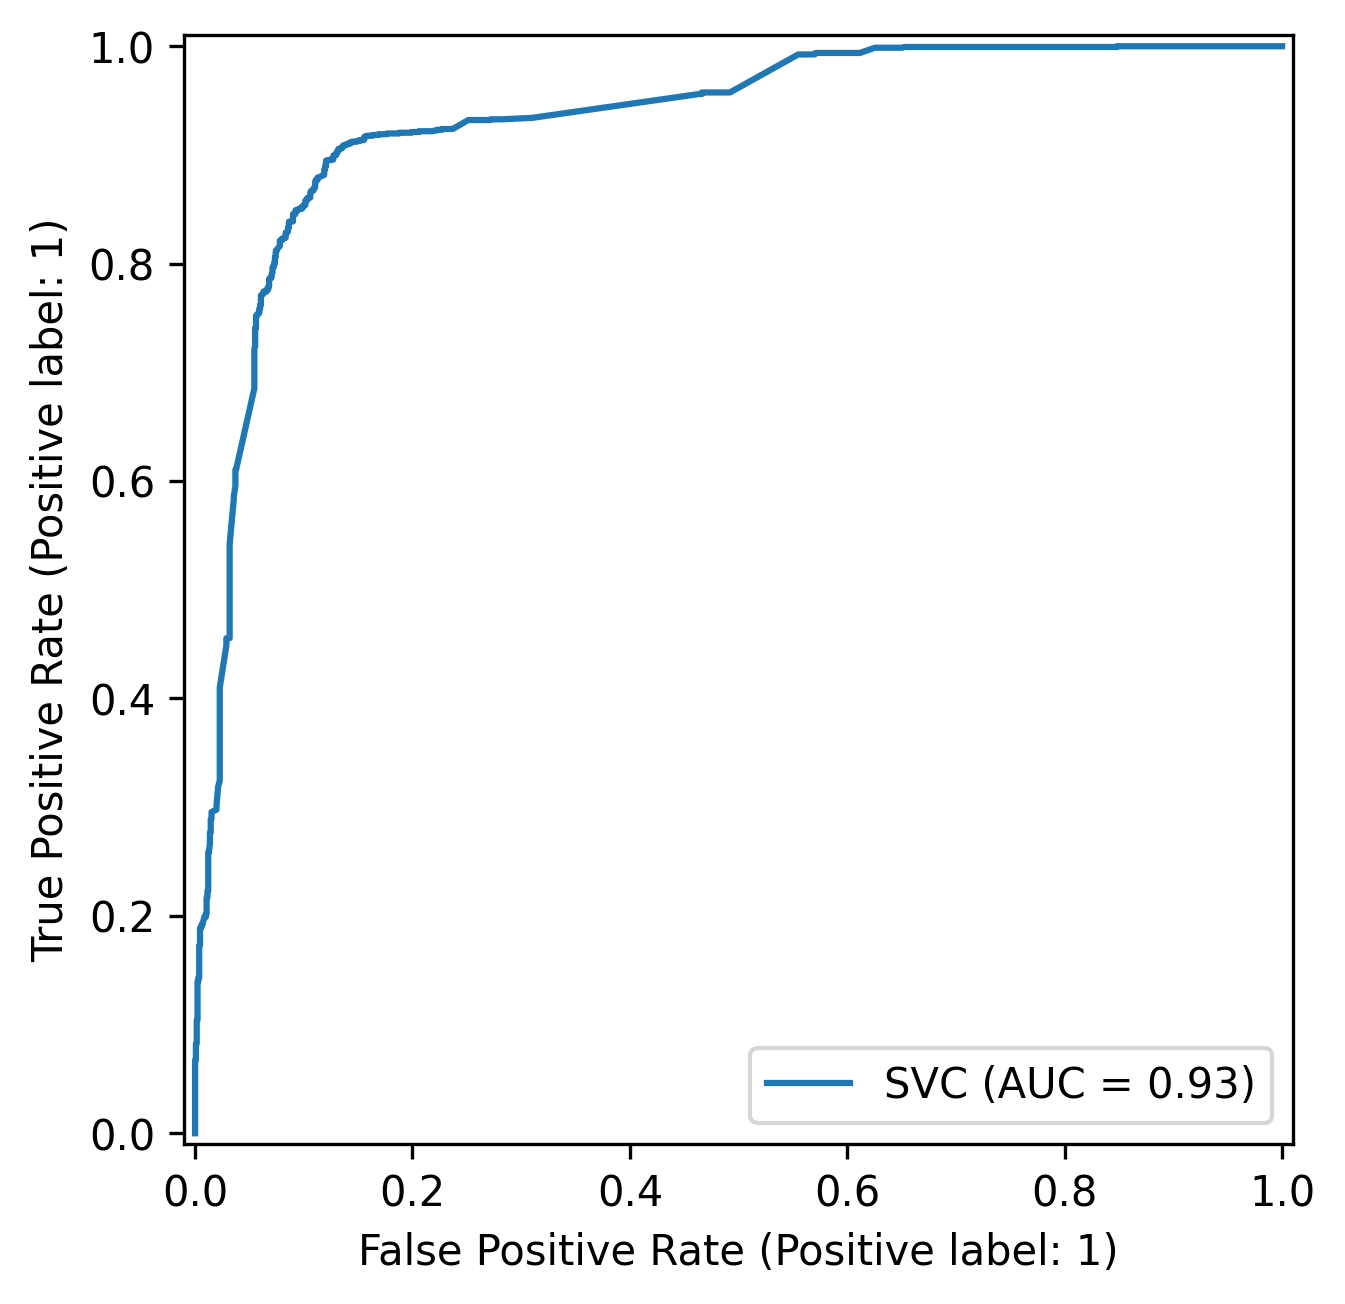

In [ ]:
from sklearn import svm

svc_clf = svm.SVC()
svc_clf.fit(train_X, train_y)

y_hat = svc_clf.predict(test_X)

print(classification_report(test_y, y_hat, output_dict=True))

RocCurveDisplay.from_estimator(svc_clf, test_X, test_y)

# SGD

{
    '0': {
        'precision': 0.8384124734231042,
        'recall': 0.8955336866010598,
        'f1-score': 0.8660322108345534,
        'support': 1321.0
    },
    '1': {
        'precision': 0.8991228070175439,
        'recall': 0.8436213991769548,
        'f1-score': 0.8704883227176221,
        'support': 1458.0
    },
    'accuracy': 0.8682979489024829,
    'macro avg': {
        'precision': 0.868767640220324,
        'recall': 0.8695775428890073,
        'f1-score': 0.8682602667760877,
        'support': 2779.0
    },
    'weighted avg': {
        'precision': 0.8702640986050736,
        'recall': 0.8682979489024829,
        'f1-score': 0.8683701061657929,
        'support': 2779.0
    }
}

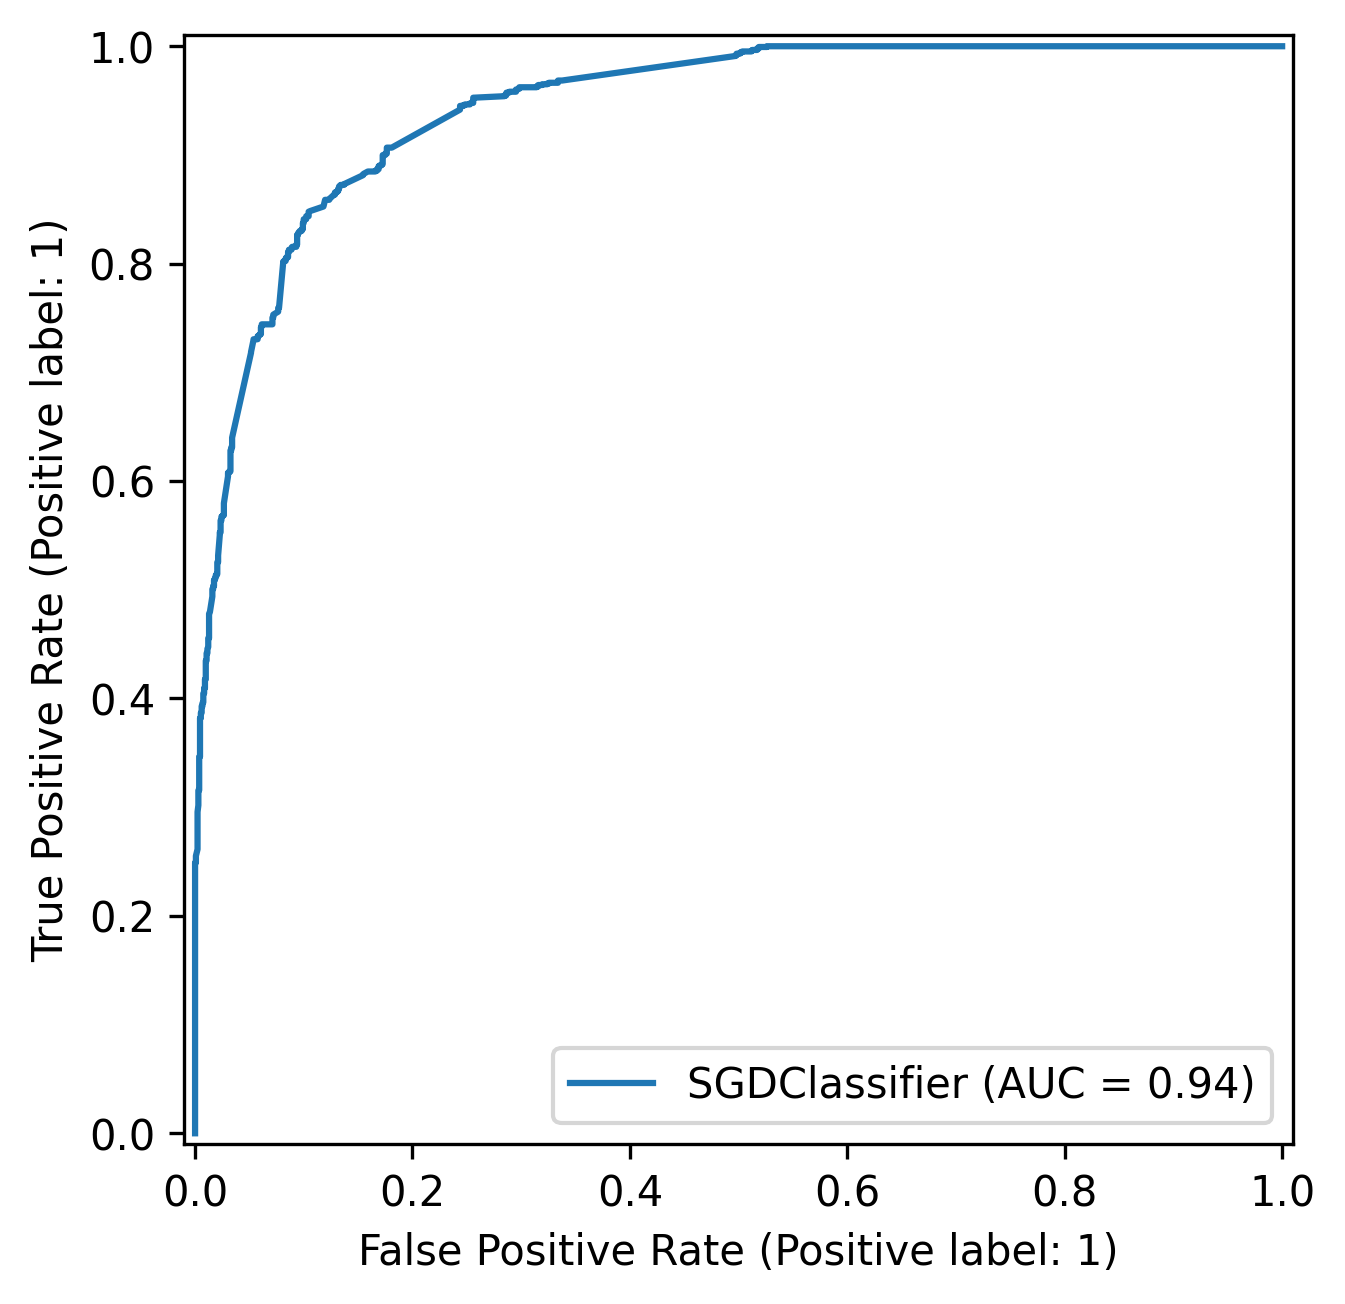

In [ ]:
from sklearn.linear_model import SGDClassifier

lr_clf = SGDClassifier(loss="log_loss")
lr_clf.fit(train_X, train_y)

y_hat = lr_clf.predict(test_X)
print(classification_report(test_y, y_hat, output_dict=True))
RocCurveDisplay.from_estimator(lr_clf, test_X, test_y)

# Decision Tree

{
    '0': {
        'precision': 0.863768115942029,
        'recall': 0.9023467070401211,
        'f1-score': 0.8826360607182525,
        'support': 1321.0
    },
    '1': {
        'precision': 0.9077912794853467,
        'recall': 0.8710562414266118,
        'f1-score': 0.8890444522226111,
        'support': 1458.0
    },
    'accuracy': 0.8859301907160849,
    'macro avg': {
        'precision': 0.8857796977136878,
        'recall': 0.8867014742333664,
        'f1-score': 0.8858402564704317,
        'support': 2779.0
    },
    'weighted avg': {
        'precision': 0.8868648314678143,
        'recall': 0.8859301907160849,
        'f1-score': 0.8859982179018994,
        'support': 2779.0
    }
}

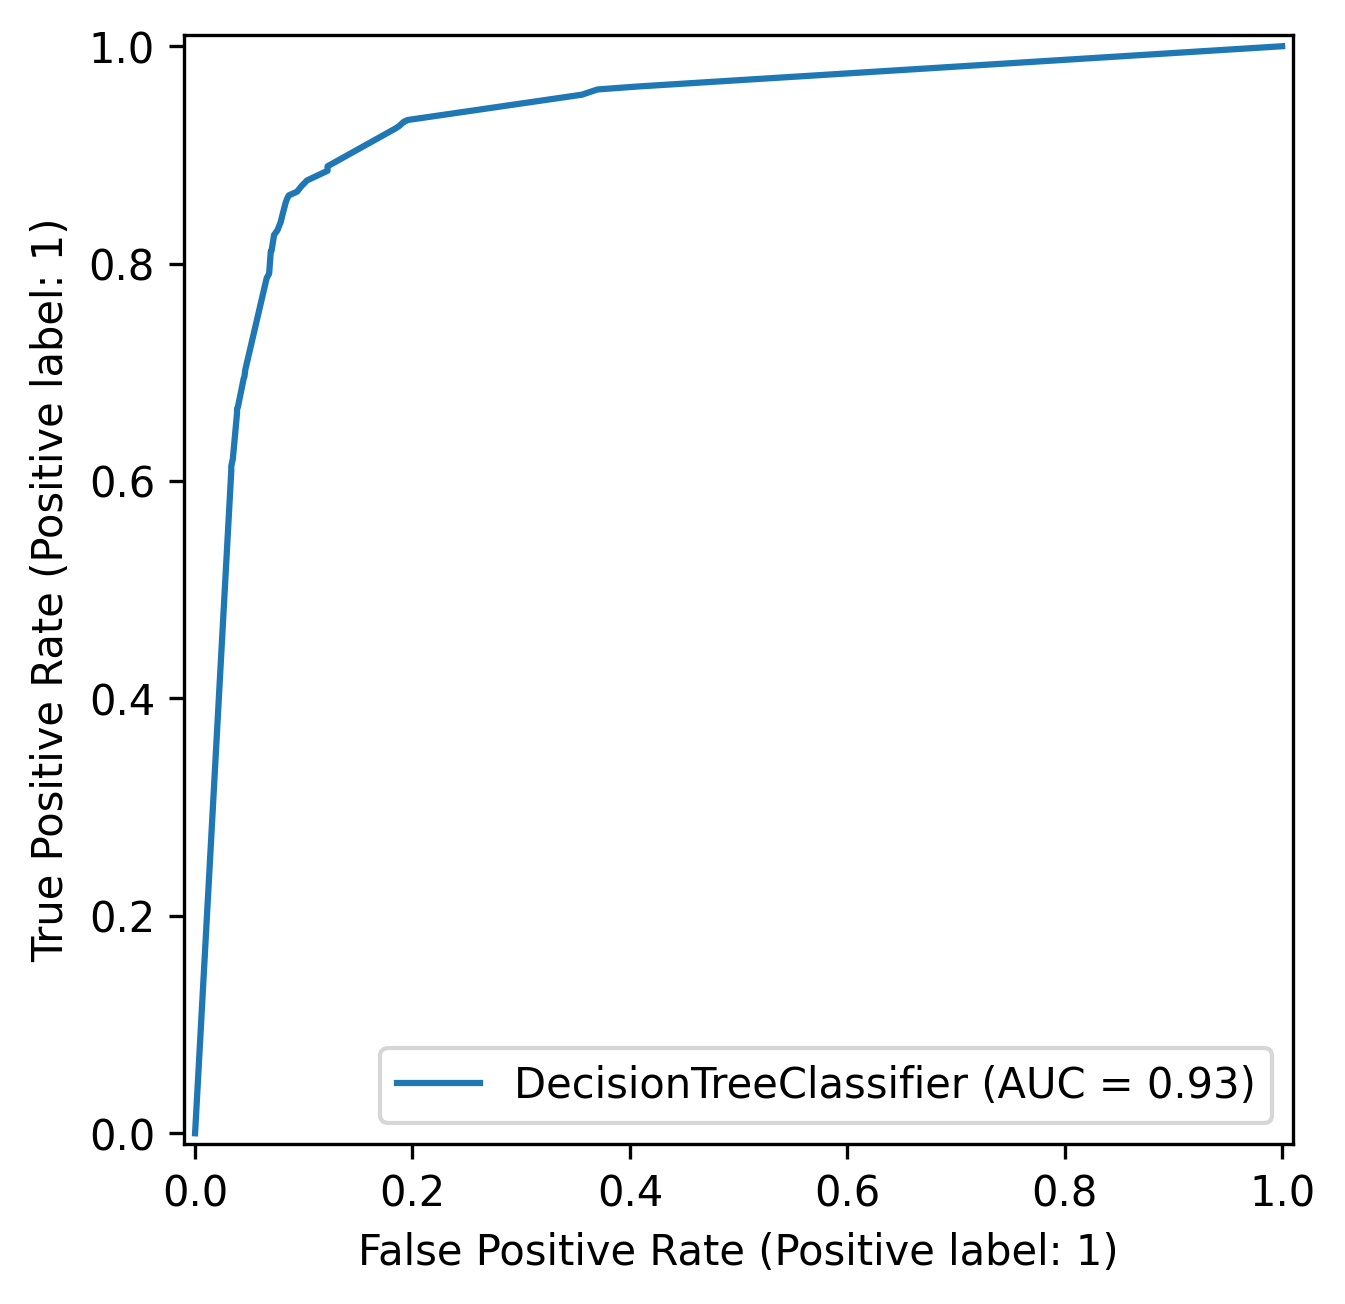

In [24]:
from sklearn import tree

dt_clf = tree.DecisionTreeClassifier()
dt_clf.fit(train_X, train_y)

y_hat = dt_clf.predict(test_X)
print(classification_report(test_y, y_hat, output_dict=True))
RocCurveDisplay.from_estimator(dt_clf, test_X, test_y)

In [8]:
print(classification_report(test_y, clf.predict(np.zeros_like(test_X))))

/Users/henrywilliams/Documents/uni/masters-thesis/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/henrywilliams/Documents/uni/masters-thesis/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/henrywilliams/Documents/uni/masters-thesis/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

precision    recall  f1-score   support

           0       0.48      1.00      0.64      1321
           1       0.00      0.00      0.00      1458

    accuracy                           0.48      2779
   macro avg       0.24      0.50      0.32      2779
weighted avg       0.23      0.48      0.31      2779

In [5]:
class Classifier(nn.Module):
    def __init__(self, in_features: int, layer_spec):
        super(Classifier, self).__init__()

        layer_spec.insert(0, in_features)

        self.model = nn.Sequential(
            *[
                nn.Sequential(
                    nn.Linear(prev_layer, layer), nn.BatchNorm1d(layer), nn.ReLU()
                )
                for prev_layer, layer in zip(layer_spec, layer_spec[1:])
            ]
            + [nn.Sequential(nn.Linear(layer_spec[-1], 2), nn.Sigmoid())]
        )

    def forward(self, x):
        return self.model(x)

In [6]:
train_ds = TensorDataset(
    torch.tensor(train_X, dtype=torch.float32),
    F.one_hot(torch.tensor(train_y), 2).to(torch.float32),
)
test_ds = TensorDataset(
    torch.tensor(test_X, dtype=torch.float32),
    F.one_hot(torch.tensor(test_y), 2).to(torch.float32),
)
np.ceil(np.sqrt(len(test_ds)))

np.float64(53.0)

In [7]:
LR = 1e-3

model = Classifier(1806, [4096, 2048, 1048, 512, 256, 128]).to(device)
criterion = nn.BCEWithLogitsLoss(reduction="sum").to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)
reports = []
losses = []
test_losses = []

In [8]:
def test(model, dataset, criterion):
    model.eval()
    predicted = []
    actual = []
    test_loss = 0.0

    test_loop = tqdm(dataset, desc=f"Test Epoch {epoch + 1}/{EPOCHS}", leave=False)

    for i, (X, y) in enumerate(test_loop):
        X = X.to(device)
        y = y.to(device)

        with torch.no_grad():
            logits = model(X)

        loss = criterion(logits, y)
        test_loss += loss.item()

        for y_hat, yi in zip(logits, y):
            predicted.append(y_hat.argmax().item())
            actual.append(yi.argmax().item())

        test_loop.set_postfix_str(f"Loss: {test_loss / (i + 1):.2f}")

    model.train()
    return test_loss / len(dataset), classification_report(
        actual, predicted, output_dict=True
    )


EPOCHS = 300
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, BATCH_SIZE)
test_loader = DataLoader(test_ds, BATCH_SIZE)


for epoch in range(EPOCHS):
    train_loop = tqdm(
        train_loader, desc=f"Train Epoch {epoch + 1}/{EPOCHS}", leave=False
    )

    for X, y in train_loop:
        X = X.to(device)
        y = y.to(device)

        optim.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        losses.append(loss.item())
        loss.backward()
        optim.step()
        train_loop.set_postfix_str(f"Loss: {loss.item():.2}")

    test_loss, report = test(model, test_loader, criterion)
    reports.append(report)
    test_losses.append(test_loss)

KeyboardInterrupt: 

/var/folders/jd/lb_vbvw54zd00wp54hlkx4_m0000gn/T/ipykernel_42112/2794738890.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


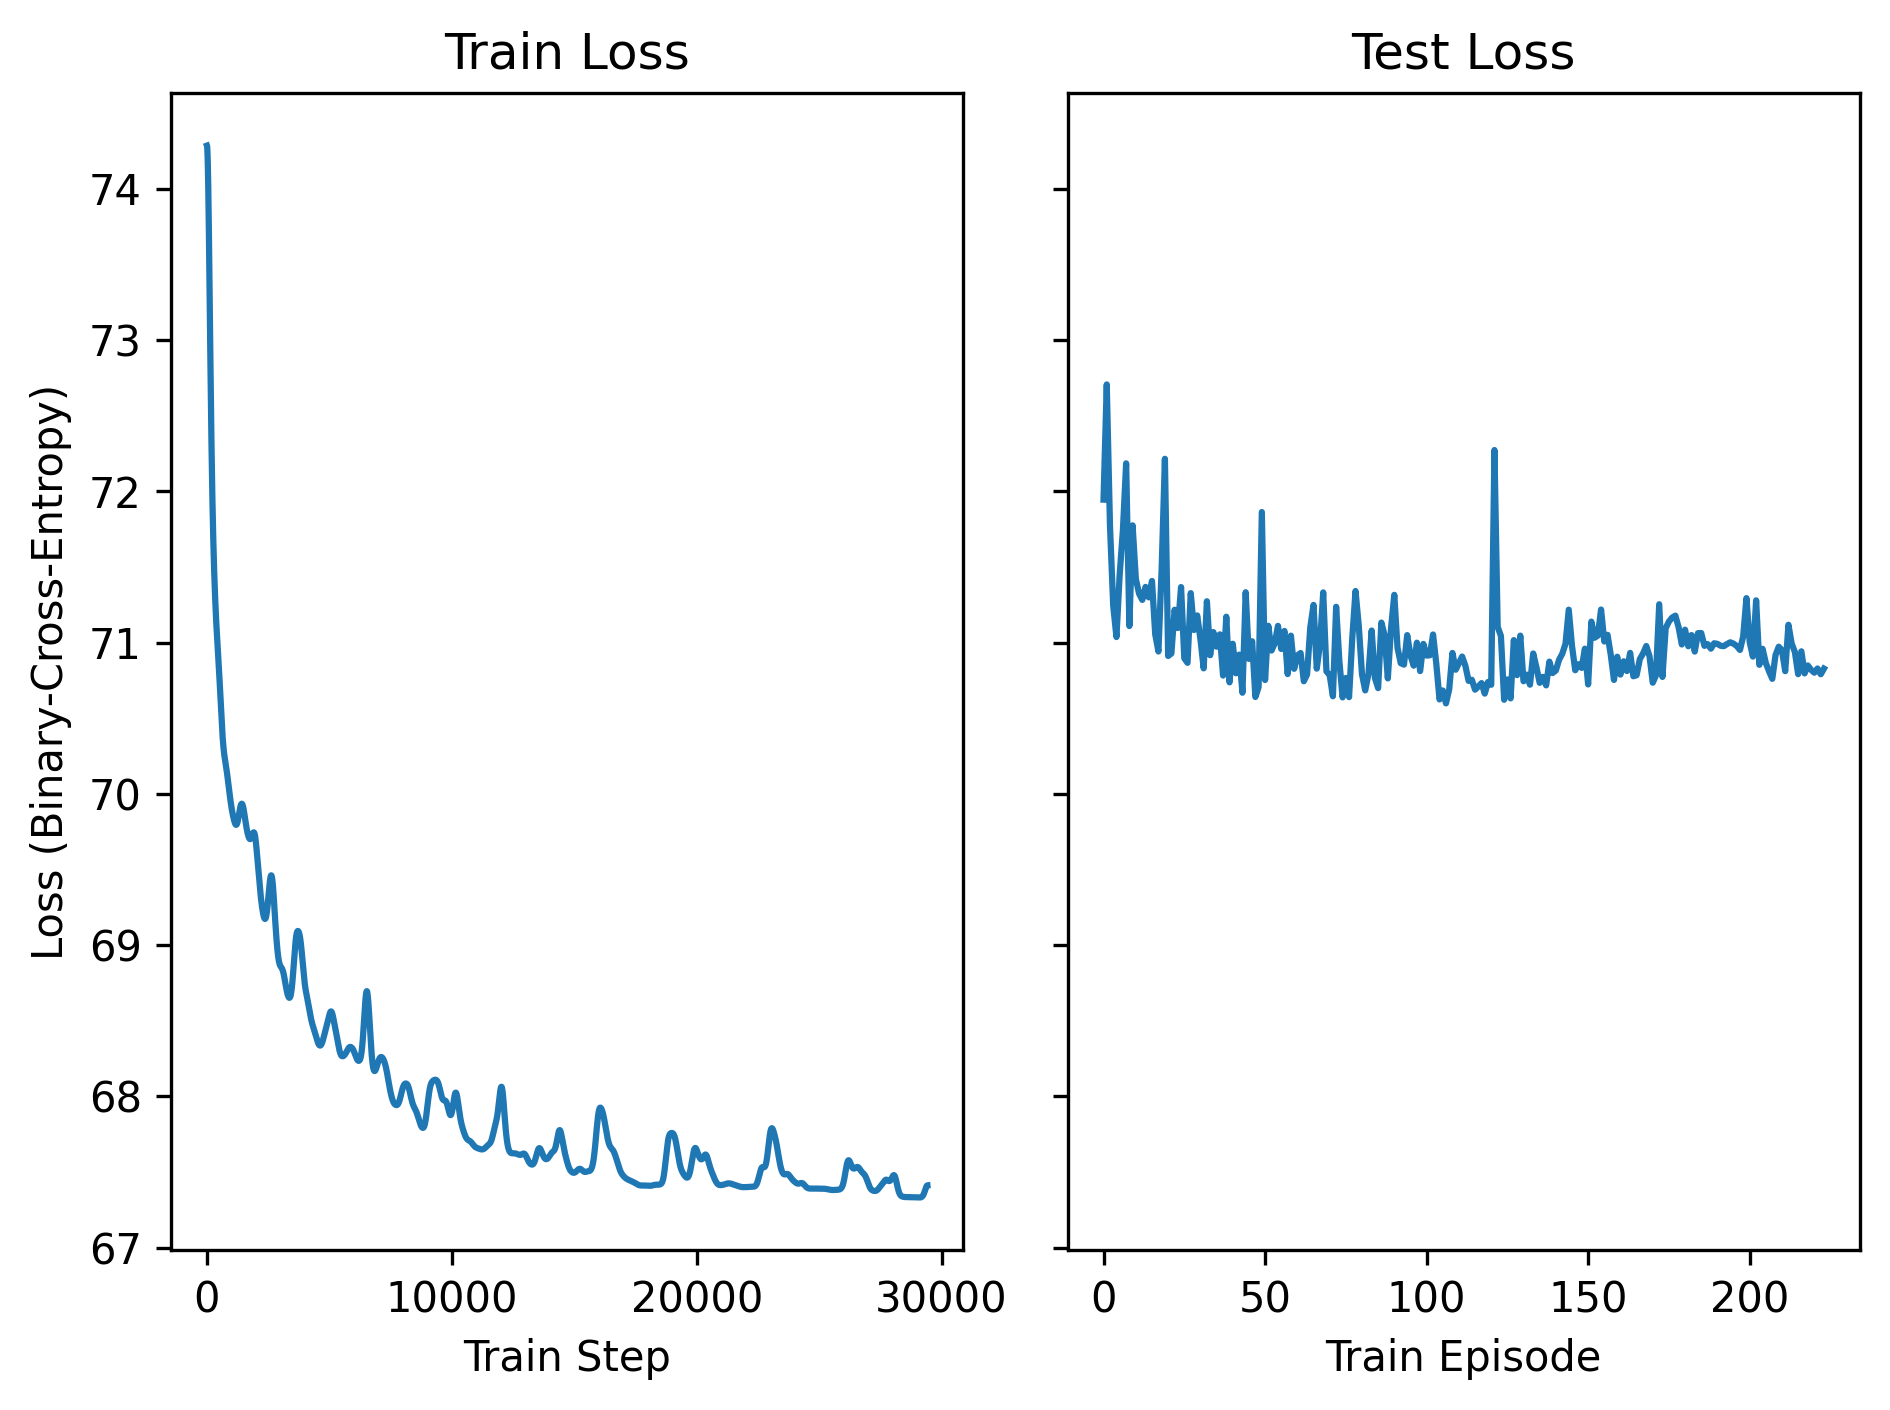

In [9]:
fig, axs = plt.subplots(1, 2, sharey=True)
fig.set_tight_layout(True)
axs[0].plot(gaussian_filter(losses, 100))
axs[0].title.set_text("Train Loss")
axs[0].set_xlabel("Train Step")
axs[0].set_ylabel("Loss (Binary-Cross-Entropy)")

axs[1].plot(test_losses)
axs[1].title.set_text("Test Loss")
axs[1].set_xlabel("Train Episode")
fig.show()

100%|██████████| 44/44 [00:00<00:00, 67.59it/s]


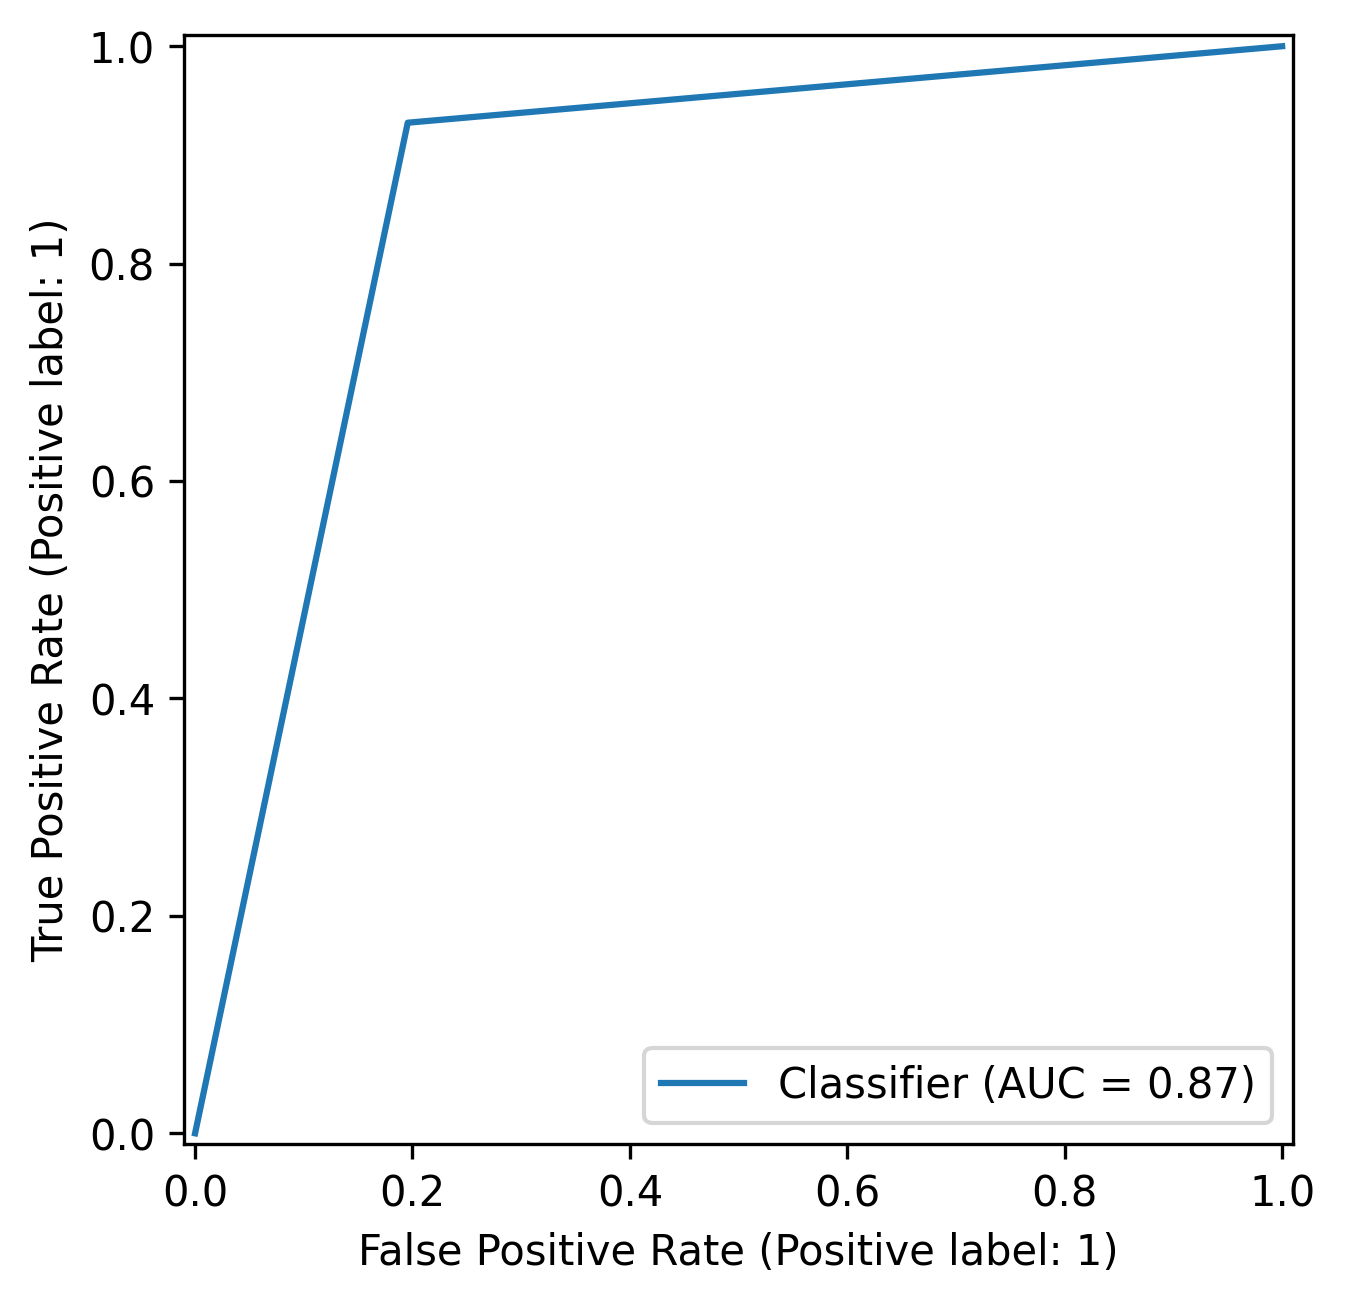

In [10]:
model.eval()

predicted = []
actual = []
for X, y in tqdm(test_loader):
    X = X.to(device)

    with torch.no_grad():
        y_hat = model(X).argmax(dim=1)

    for yi_hat, yi in zip(y_hat, y):
        predicted.append(yi_hat.cpu())
        actual.append(yi.argmax())
actual = np.array(actual)
predicted = np.array(predicted)
RocCurveDisplay.from_predictions(actual, predicted)

In [ ]:
(np.array(predicted) == np.array(actual)).shape

(2779,)

In [ ]:
df = pd.DataFrame(
    {
        ("Accuracy", ""): [report["accuracy"] for report in reports],
        ("Benign", "Precision"): [report["0"]["precision"] for report in reports],
        ("Benign", "Recall"): [report["0"]["recall"] for report in reports],
        ("Benign", "F1"): [report["0"]["f1-score"] for report in reports],
        ("Malicious", "Precision"): [report["1"]["precision"] for report in reports],
        ("Malicious", "Recall"): [report["1"]["recall"] for report in reports],
        ("Malicious", "F1"): [report["1"]["f1-score"] for report in reports],
        ("Macro Average", "Precision"): [
            report["macro avg"]["precision"] for report in reports
        ],
        ("Macro Average", "Recall"): [
            report["macro avg"]["recall"] for report in reports
        ],
        ("Macro Average", "F1"): [
            report["macro avg"]["f1-score"] for report in reports
        ],
        ("Weighted Average", "Precision"): [
            report["weighted avg"]["precision"] for report in reports
        ],
        ("Weighted Average", "Recall"): [
            report["weighted avg"]["recall"] for report in reports
        ],
        ("Weighted Average", "F1"): [
            report["weighted avg"]["f1-score"] for report in reports
        ],
    }
)

df.columns = pd.MultiIndex.from_tuples(df.columns)
df

Accuracy    Benign                     Malicious                      \
               Precision    Recall        F1 Precision    Recall        F1   
0     0.874415  0.878067  0.857678  0.867753  0.871186  0.889889  0.880439   
1     0.866499  0.858631  0.864419  0.861515  0.873868  0.868421  0.871136   
2     0.877294  0.884080  0.856929  0.870293  0.871380  0.896122  0.883578   
3     0.875135  0.877676  0.859925  0.868710  0.872876  0.889197  0.880961   
4     0.865419  0.871616  0.844195  0.857686  0.860027  0.885042  0.872355   
...        ...       ...       ...       ...       ...       ...       ...   
1995  0.879813  0.872119  0.878652  0.875373  0.887029  0.880886  0.883947   
1996  0.879453  0.872024  0.877903  0.874953  0.886411  0.880886  0.883640   
1997  0.880173  0.872214  0.879401  0.875793  0.887648  0.880886  0.884254   
1998  0.879453  0.872024  0.877903  0.874953  0.886411  0.880886  0.883640   
1999  0.879453  0.872024  0.877903  0.874953  0.886411  0.880886  0.883640   

     Macro Average                     Weighted Average                      
         Precision    Recall        F1        Precision    Recall        F1  
0         0.874627  0.873784  0.874096         0.874492  0.874415  0.874345  
1         0.866249  0.866420  0.866326         0.866548  0.866499  0.866514  
2         0.877730  0.876525  0.876935         0.877481  0.877294  0.877196  
3         0.875276  0.874561  0.874835         0.875182  0.875135  0.875075  
4         0.865822  0.864618  0.865021         0.865594  0.865419  0.865308  
...            ...       ...       ...              ...       ...       ...  
1995      0.879574  0.879769  0.879660         0.879867  0.879813  0.879828  
1996      0.879217  0.879395  0.879297         0.879500  0.879453  0.879467  
1997      0.879931  0.880144  0.880024         0.880234  0.880173  0.880189  
1998      0.879217  0.879395  0.879297         0.879500  0.879453  0.879467  
1999      0.879217  0.879395  0.879297         0.879500  0.879453  0.879467  

[2000 rows x 13 columns]

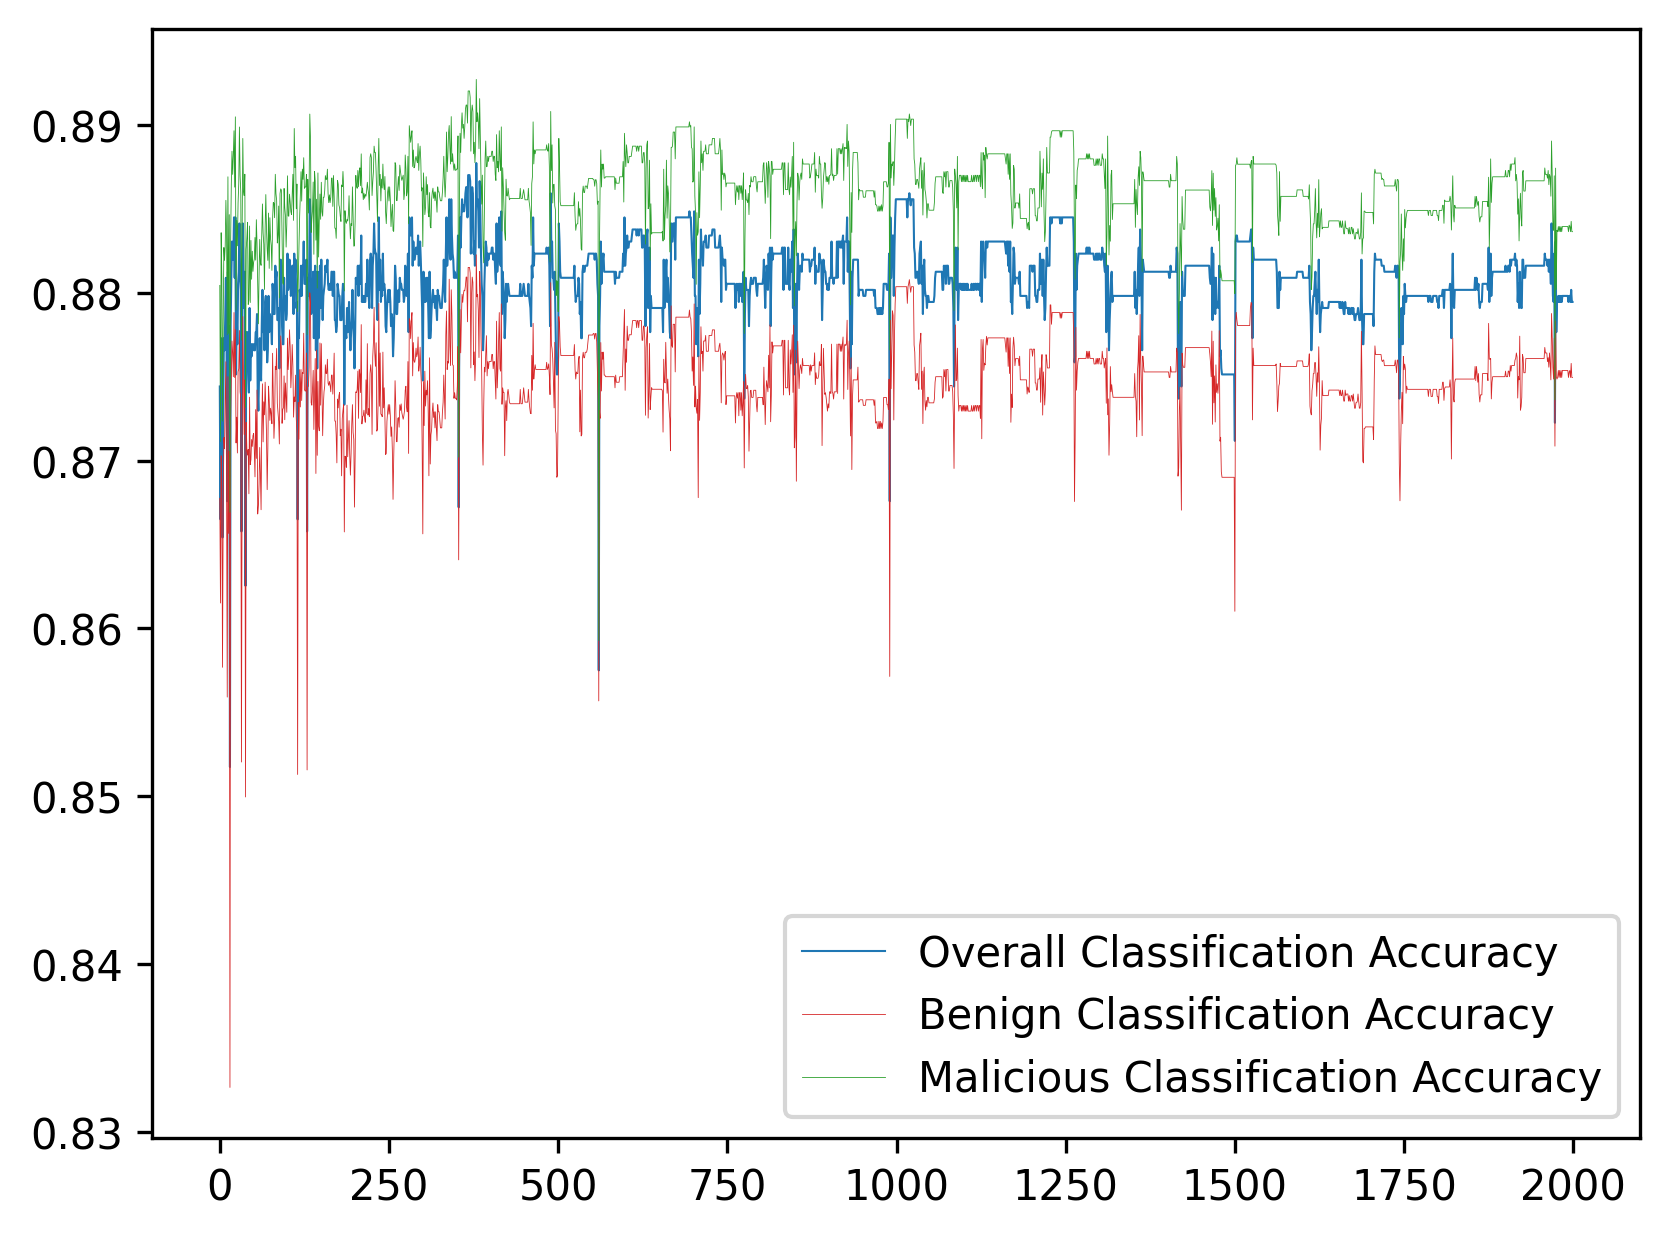

In [ ]:
plt.plot(df["Accuracy"], label="Overall Classification Accuracy", c="tab:blue", lw=0.5)
plt.plot(
    df["Benign", "F1"], label="Benign Classification Accuracy", c="tab:red", lw=0.2
)
plt.plot(
    df["Malicious", "F1"],
    label="Malicious Classification Accuracy",
    c="tab:green",
    lw=0.2,
)
plt.legend()
plt.show()

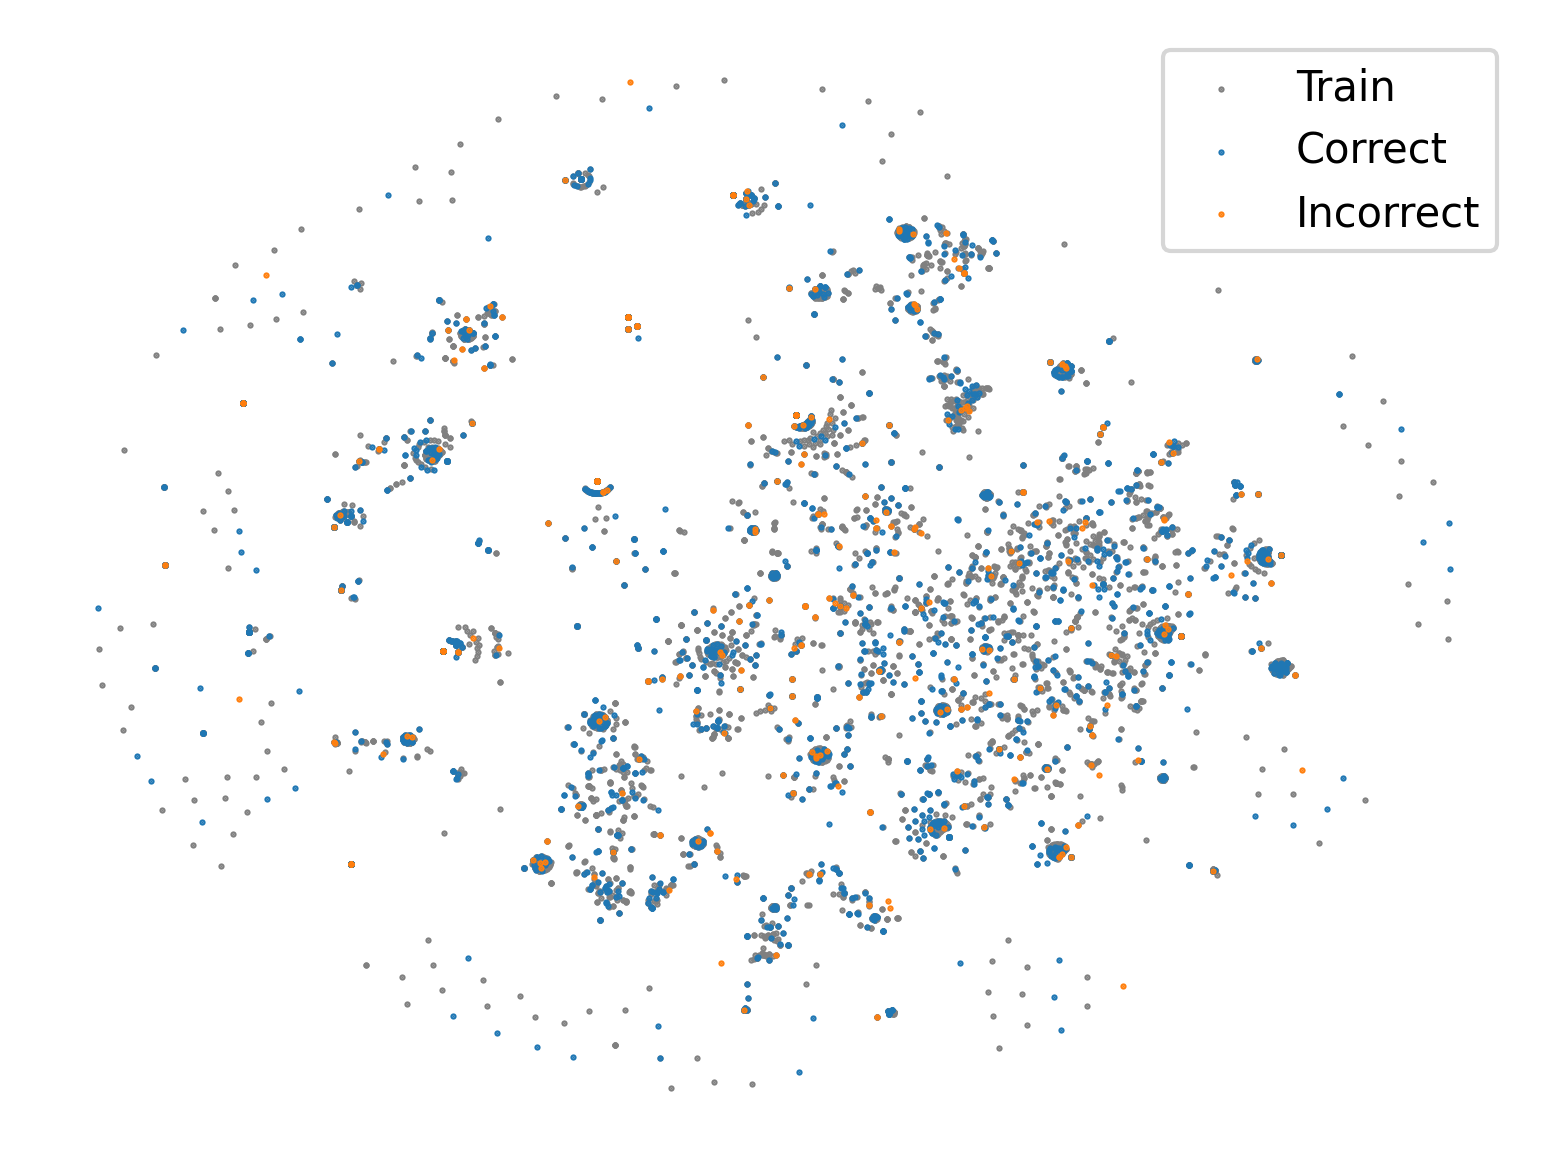

In [ ]:
from sklearn.manifold import MDS, TSNE
from sklearn.decomposition import PCA

pca = TSNE(n_components=2)
X_hat = pca.fit_transform(dll_matrix)
train_mask = np.isin(np.arange(0, len(dll_matrix)), train_idxs)
test_mask = np.invert(train_mask)
plt.scatter(X_hat[train_mask, 0], X_hat[train_mask, 1], c="gray", s=0.25, label="Train")
plt.scatter(
    X_hat[test_mask, 0][actual == predicted],
    X_hat[test_mask, 1][actual == predicted],
    c="tab:blue",
    s=0.25,
    label="Correct",
)
plt.scatter(
    X_hat[test_mask, 0][actual != predicted],
    X_hat[test_mask, 1][actual != predicted],
    c="tab:orange",
    s=0.25,
    label="Incorrect",
)
plt.legend()
plt.axis("off")
plt.show()

In [ ]:
obfuscated_X_test = np.zeros_like(test_X)
ps = np.linspace(0.0, 1.0, 10)

mask = np.random.random(len(test_X))

for p in ps:
    xi = np.where(mask[:, None] > p, test_X, obfuscated_X_test)
    yi_hat = dt_clf.predict(xi)

    print(classification_report(test_y, yi_hat, output_dict=True)["accuracy"])

0.8859301907160849

0.8384310903202591

0.7920115149334293

0.7495501979129183

0.7031306225260885

...

0.6149694134580784

0.5696293630802447

0.5199712126664268

/Users/henrywilliams/Documents/uni/masters-thesis/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/henrywilliams/Documents/uni/masters-thesis/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/henrywilliams/Documents/uni/masters-thesis/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

0.47535084562792373